In [ ]:
import pandas as _hex_pandas
import datetime as _hex_datetime
import json as _hex_json

In [ ]:
hex_scheduled = _hex_json.loads("false")

In [ ]:
hex_user_email = _hex_json.loads("\"example-user@example.com\"")

In [ ]:
hex_user_attributes = _hex_json.loads("{}")

In [ ]:
hex_run_context = _hex_json.loads("\"logic\"")

In [ ]:
hex_timezone = _hex_json.loads("\"UTC\"")

In [ ]:
hex_project_id = _hex_json.loads("\"019e0850-a0ae-7000-8193-6d0c5740f344\"")

In [ ]:
hex_project_name = _hex_json.loads("\"IBM_Telco_customer_churn\"")

In [ ]:
hex_status = _hex_json.loads("\"\"")

In [ ]:
hex_categories = _hex_json.loads("[]")

In [ ]:
hex_color_palette = _hex_json.loads("[\"#4C78A8\",\"#F58518\",\"#E45756\",\"#72B7B2\",\"#54A24B\",\"#EECA3B\",\"#B279A2\",\"#FF9DA6\",\"#9D755D\",\"#BAB0AC\"]")

In [ ]:
# import jinja2
# raw_query = """
#     select * from "IBM_Telco_Customer_Churn.csv";
# """
# sql_query = jinja2.Template(raw_query).render(vars())

In [ ]:
import pandas as pd
import numpy as np

df = IBM_Telco_Customer_Churn.copy()

shape = df.shape
dtypes = df.dtypes.astype(str)

# TotalCharges is text — coerce
tc_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
tc_blank_mask = tc_numeric.isna()
blank_total_charges = int(tc_blank_mask.sum())
blank_tc_tenure_zero = int((tc_blank_mask & (df["tenure"] == 0)).sum())

df["TotalCharges"] = tc_numeric

null_counts = df.isna().sum()
null_counts = null_counts[null_counts > 0]

dup_full = int(df.duplicated().sum())
dup_customer_id = int(df["customerID"].duplicated().sum())

def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), float(lo), float(hi), float(s.min()), float(s.max())

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
outlier_rows = []
for c in numeric_cols:
    n, lo, hi, mn, mx = iqr_outliers(df[c].dropna())
    outlier_rows.append({"column": c, "min": mn, "max": mx, "iqr_low": lo, "iqr_high": hi, "outliers_iqr": n})
outliers_df = pd.DataFrame(outlier_rows)

numeric_summary = df[numeric_cols].describe().T

print("Shape:", shape)
print("\nDtypes:\n", dtypes.to_string())
print("\nBlank TotalCharges (non-numeric):", blank_total_charges, "| of which tenure==0:", blank_tc_tenure_zero)
print("\nMissing after coercion:\n", null_counts.to_string() if len(null_counts) else "none")
print("\nFully duplicated rows:", dup_full)
print("Duplicate customerID:", dup_customer_id)
print("\nNumeric summary:\n", numeric_summary.to_string())
print("\nOutliers (IQR 1.5x):\n", outliers_df.to_string(index=False))

Shape: (7043, 21)

Dtypes:
 customerID           object
gender               object
SeniorCitizen         int64
Partner                bool
Dependents             bool
tenure                int64
PhoneService           bool
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling       bool
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                  bool

Blank TotalCharges (non-numeric): 11 | of which tenure==0: 11

Missing after coercion:
 TotalCharges    11

Fully duplicated rows: 0
Duplicate customerID: 0

Numeric summary:
                  count         mean          std    min     25%       50%        75%      max
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000    55.0000    72.00
MonthlyCharges  704

In [ ]:
df_clean = IBM_Telco_Customer_Churn.copy()
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["SeniorCitizen"] = np.where(df_clean["SeniorCitizen"] == 1, "Yes", "No")
df_clean[["customerID", "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,7590-VHVEG,No,1,29.85,29.85
1,5575-GNVDE,No,34,56.95,1889.50
2,3668-QPYBK,No,2,53.85,108.15
3,7795-CFOCW,No,45,42.30,1840.75
4,9237-HQITU,No,2,70.70,151.65


In [ ]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,True,False,1,False,No phone service,DSL,No,...,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,5575-GNVDE,Male,No,False,False,34,True,No,DSL,Yes,...,Yes,No,No,No,One year,False,Mailed check,56.95,1889.50,False
2,3668-QPYBK,Male,No,False,False,2,True,No,DSL,Yes,...,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,7795-CFOCW,Male,No,False,False,45,False,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,9237-HQITU,Female,No,False,False,2,True,No,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,True


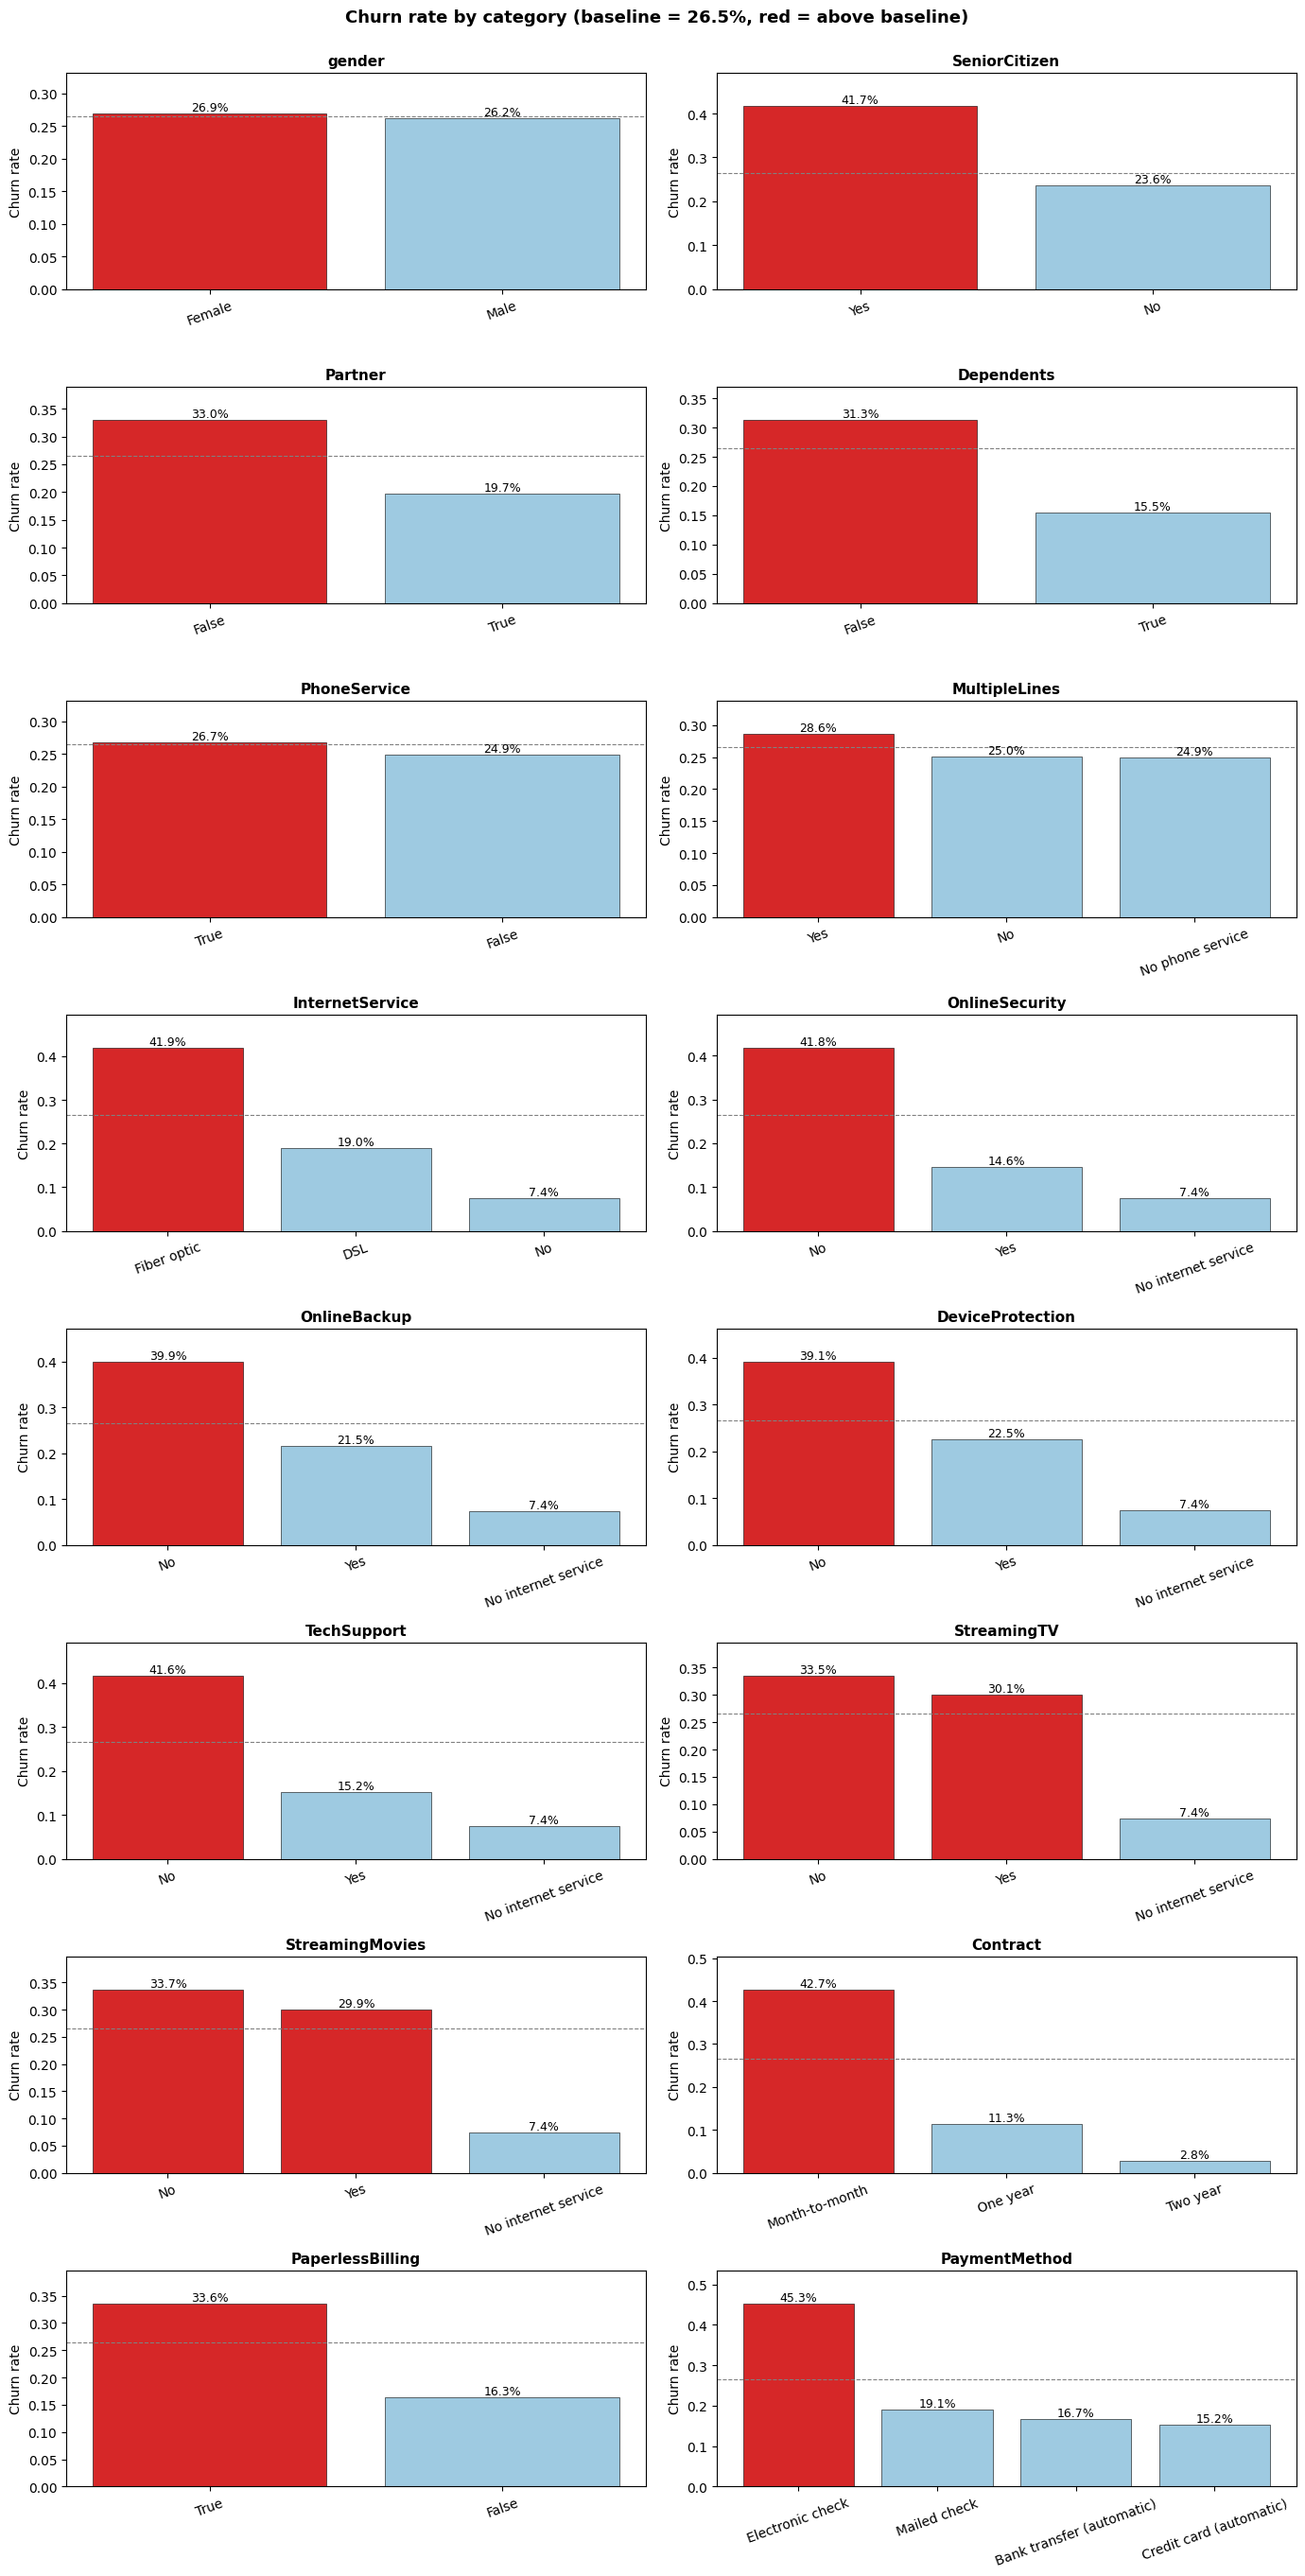

In [ ]:
cat_cols = [c for c in df_clean.select_dtypes(include=["object", "bool"]).columns
            if c not in ("customerID", "Churn")]

baseline = 0.265
n = len(cat_cols)
ncols = 2
nrows = (n + 1) // 2

import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows))
axes = axes.flatten()

churn_num = df_clean["Churn"].astype(int)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    rates = (churn_num.groupby(df_clean[col].astype(str)).mean()
             .sort_values(ascending=False))
    colors = ["#d62728" if v > baseline else "#9ecae1" for v in rates.values]
    bars = ax.bar(rates.index, rates.values, color=colors, edgecolor="black", linewidth=0.4)
    ax.axhline(baseline, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Churn rate")
    ax.set_ylim(0, max(rates.max() * 1.18, baseline * 1.25))
    ax.tick_params(axis="x", rotation=20)
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}",
                ha="center", va="bottom", fontsize=9)

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Churn rate by category (baseline = {baseline:.1%}, red = above baseline)",
             fontsize=13, fontweight="bold", y=1.00)
fig.tight_layout()
plt.show()

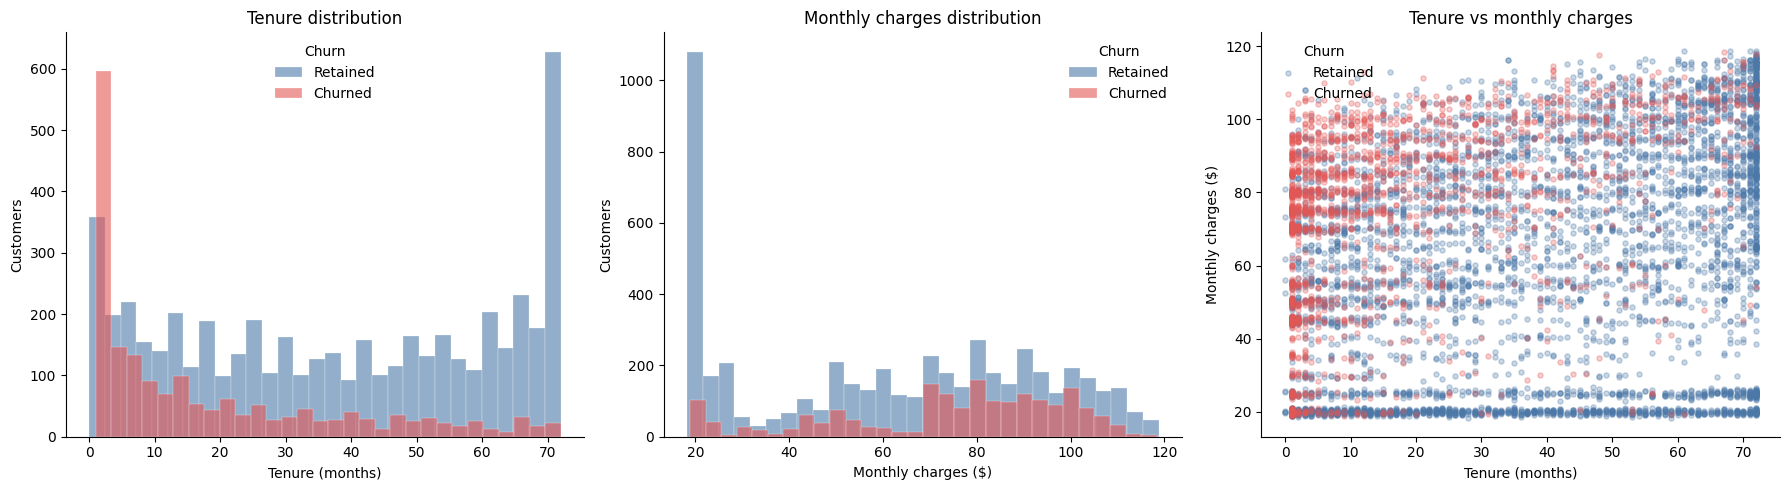

In [ ]:
import matplotlib.pyplot as plt

palette = {False: "#4c78a8", True: "#e45756"}
labels = {False: "Retained", True: "Churned"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for status in [False, True]:
    sub = df_clean[df_clean["Churn"] == status]
    axes[0].hist(sub["tenure"], bins=30, alpha=0.6, color=palette[status],
                 label=labels[status], edgecolor="white", linewidth=0.3)
    axes[1].hist(sub["MonthlyCharges"], bins=30, alpha=0.6, color=palette[status],
                 label=labels[status], edgecolor="white", linewidth=0.3)
    axes[2].scatter(sub["tenure"], sub["MonthlyCharges"], alpha=0.3, s=14,
                    color=palette[status], label=labels[status])

axes[0].set(title="Tenure distribution", xlabel="Tenure (months)", ylabel="Customers")
axes[1].set(title="Monthly charges distribution", xlabel="Monthly charges ($)", ylabel="Customers")
axes[2].set(title="Tenure vs monthly charges", xlabel="Tenure (months)", ylabel="Monthly charges ($)")

for ax in axes:
    ax.legend(title="Churn", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
bins = [0, 12, 36, 72]
labels = ["0-12", "13-36", "37-72"]

seg = df_clean.assign(
    tenure_bucket=pd.cut(df_clean["tenure"], bins=bins, labels=labels, include_lowest=True),
    churn_int=df_clean["Churn"].astype(int),
)

segments = (seg.groupby(["Contract", "InternetService", "tenure_bucket"], observed=True)
              .agg(count=("churn_int", "size"),
                   churn_rate=("churn_int", "mean"),
                   avg_monthly_charges=("MonthlyCharges", "mean"))
              .reset_index()
              .sort_values("churn_rate", ascending=False)
              .head(15)
              .reset_index(drop=True))

segments.style.format({
    "churn_rate": "{:.1%}",
    "avg_monthly_charges": "${:,.2f}",
}).apply(lambda r: ["background-color: #fde0dc" if r["churn_rate"] > 0.5 else "" for _ in r], axis=1)

,Contract,InternetService,tenure_bucket,count,churn_rate,avg_monthly_charges
0,Month-to-month,Fiber optic,0-12,916,70.2%,$82.08
1,Month-to-month,Fiber optic,13-36,734,48.2%,$88.59
2,Month-to-month,DSL,0-12,690,42.5%,$47.88
3,Month-to-month,Fiber optic,37-72,478,34.5%,$94.09
4,One year,Fiber optic,0-12,7,28.6%,$95.04
5,Month-to-month,No,0-12,388,22.7%,$20.27
6,Month-to-month,DSL,13-36,369,19.5%,$53.37
7,One year,Fiber optic,37-72,447,19.2%,$99.89
8,One year,Fiber optic,13-36,85,18.8%,$93.25
9,Month-to-month,DSL,37-72,164,17.7%,$52.97


In [ ]:
import sys, site, importlib
for p in ["/usr/lib/python3.12/site-packages", site.getusersitepackages()]:
    if p not in sys.path:
        sys.path.insert(0, p)
importlib.invalidate_caches()
import sklearn, scipy, shap
print(sklearn.__version__, scipy.__version__, shap.__version__)

1.8.0 1.17.1 0.51.0


In [ ]:
import sklearn  # ensure available
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

data = df_clean.drop(columns=["customerID"]).dropna()
y = data["Churn"].astype(int)
X = data.drop(columns=["Churn"])

numeric_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols_x = [c for c in X.columns if c not in numeric_cols]

X_enc = pd.get_dummies(X, columns=cat_cols_x, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_s[numeric_cols] = scaler.transform(X_test[numeric_cols])

models = {
    "Logistic Regression": (LogisticRegression(max_iter=2000, random_state=42),
                            X_train_s, X_test_s),
    "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                      X_train, X_test),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),
                          X_train, X_test),
}

rows = []
roc_data = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, proba),
    })
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, rows[-1]["ROC AUC"])

results = pd.DataFrame(rows).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
results.style.format({c: "{:.3f}" for c in
                      ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]}) \
             .background_gradient(subset=["ROC AUC", "F1"], cmap="Greens")

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Gradient Boosting,0.795,0.638,0.532,0.580,0.841
1,Logistic Regression,0.805,0.650,0.572,0.609,0.836
2,Random Forest,0.787,0.624,0.497,0.554,0.820


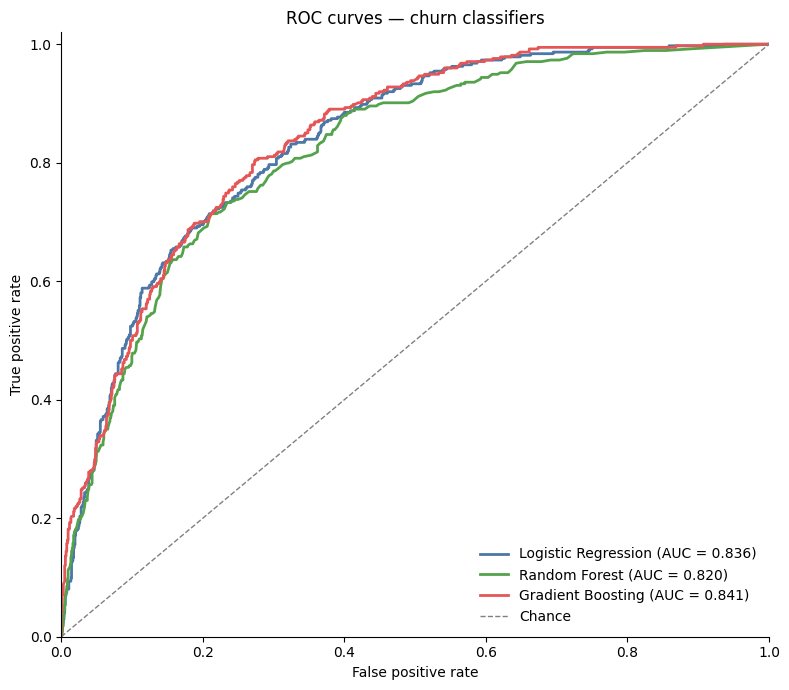

In [ ]:
import matplotlib.pyplot as plt

colors = {"Logistic Regression": "#4c78a8", "Random Forest": "#54a24b", "Gradient Boosting": "#e45756"}

fig, ax = plt.subplots(figsize=(8, 7))
for name, (fpr, tpr, auc) in roc_data.items():
    ax.plot(fpr, tpr, color=colors[name], lw=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Chance")
ax.set(xlabel="False positive rate", ylabel="True positive rate",
       title="ROC curves — churn classifiers", xlim=(0, 1), ylim=(0, 1.02))
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

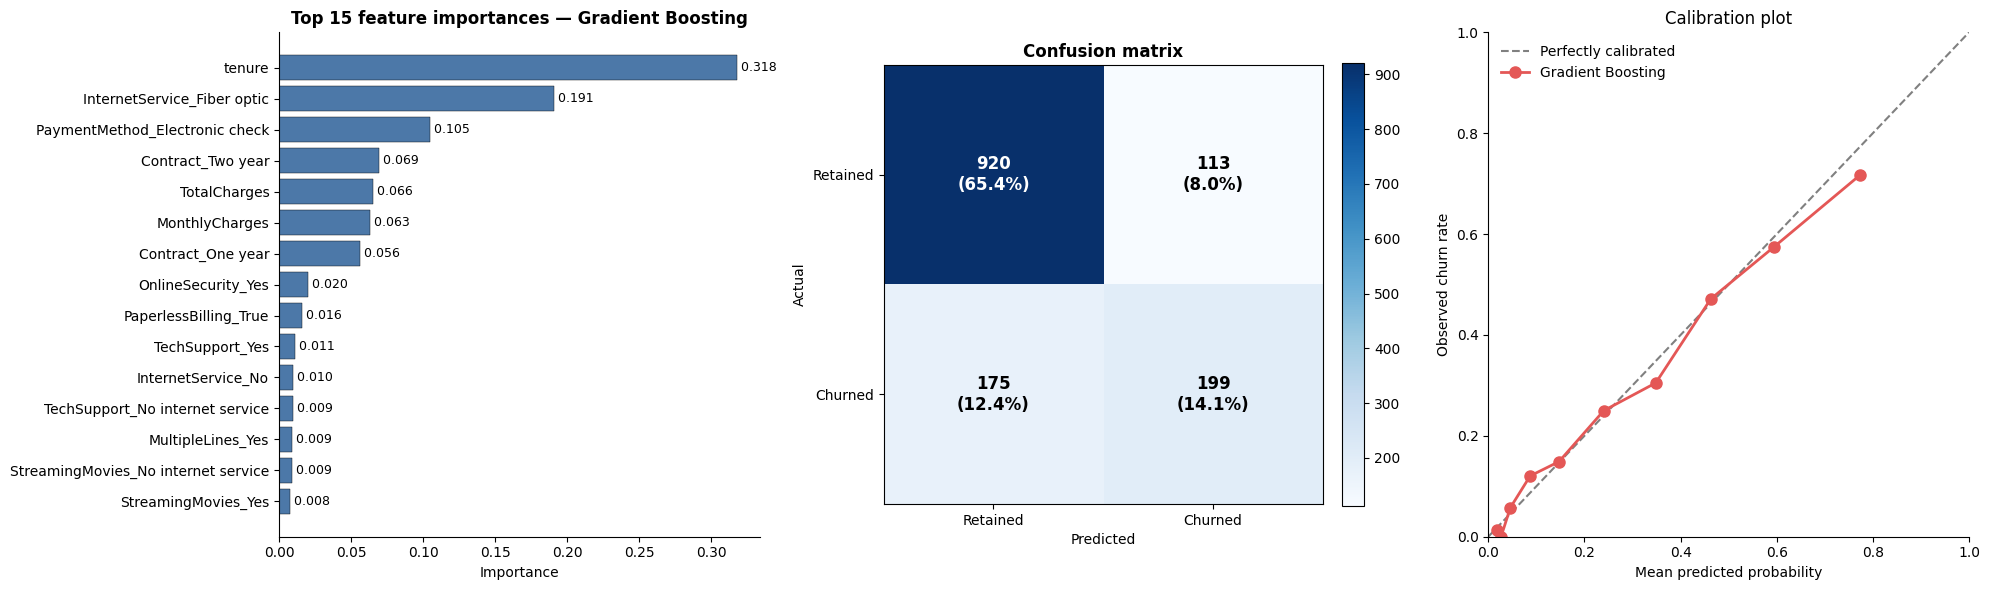

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

best_name = "Gradient Boosting"
best_model, Xtr_b, Xte_b = models[best_name]
proba_b = best_model.predict_proba(Xte_b)[:, 1]
pred_b = best_model.predict(Xte_b)

importances = (pd.Series(best_model.feature_importances_, index=Xtr_b.columns)
                 .sort_values(ascending=True).tail(15))

cm = confusion_matrix(y_test, pred_b)
cm_pct = cm / cm.sum() * 100

prob_true, prob_pred = calibration_curve(y_test, proba_b, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
ax.barh(importances.index, importances.values, color="#4c78a8", edgecolor="black", linewidth=0.3)
ax.set_title(f"Top 15 feature importances — {best_name}", fontweight="bold")
ax.set_xlabel("Importance")
for i, v in enumerate(importances.values):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Retained", "Churned"]); ax.set_yticklabels(["Retained", "Churned"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix", fontweight="bold")
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)",
                ha="center", va="center", color=color, fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[2]
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, "o-", color="#e45756", lw=2, markersize=8, label=best_name)
ax.set(xlabel="Mean predicted probability", ylabel="Observed churn rate",
       title="Calibration plot", xlim=(0, 1), ylim=(0, 1))
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
import json as _hex_json

in_gender = _hex_json.loads("\"Male\"")

In [ ]:
import json as _hex_json

in_senior = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_partner = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_dependents = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_phone_service = _hex_json.loads("\"Yes\"")

In [ ]:
import json as _hex_json

in_multiple_lines = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_internet_service = _hex_json.loads("\"Fiber optic\"")

In [ ]:
import json as _hex_json

in_online_security = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_online_backup = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_device_protection = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_tech_support = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_streaming_tv = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_streaming_movies = _hex_json.loads("\"No\"")

In [ ]:
import json as _hex_json

in_contract = _hex_json.loads("\"Month-to-month\"")

In [ ]:
import json as _hex_json

in_paperless = _hex_json.loads("\"Yes\"")

In [ ]:
import json as _hex_json

in_payment_method = _hex_json.loads("\"Electronic check\"")

In [ ]:
import json as _hex_json

in_tenure = _hex_json.loads("12")

In [ ]:
import json as _hex_json

in_monthly_charges = _hex_json.loads("70")

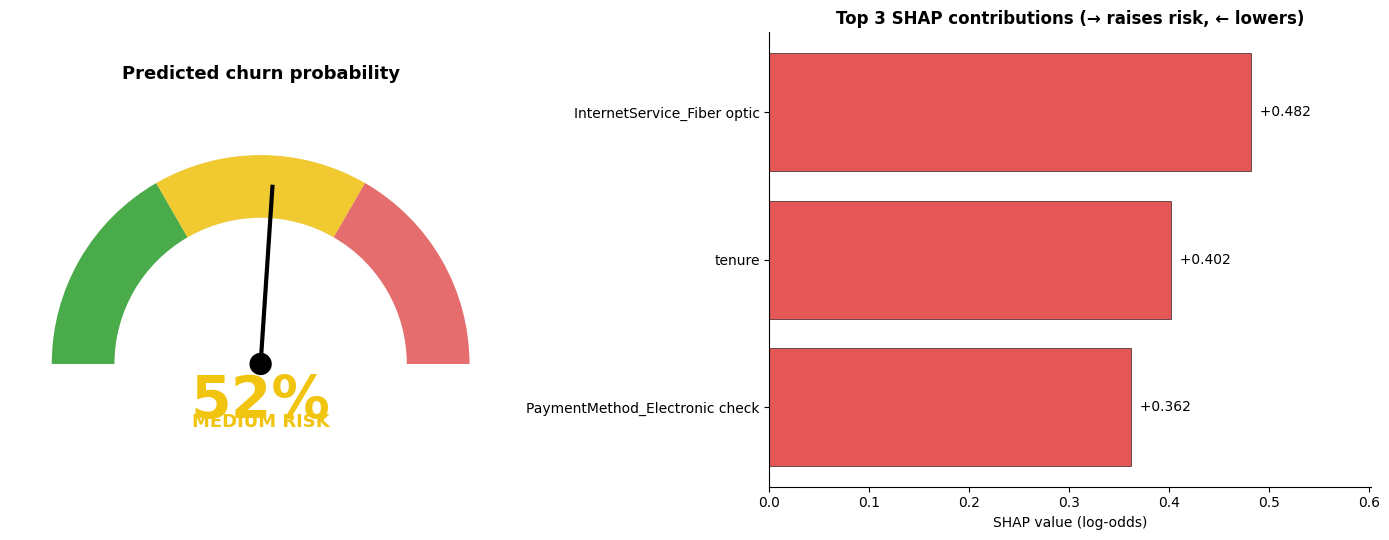

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Wedge

gbm = models["Gradient Boosting"][0]
feature_cols = X_enc.columns

def yn_to_bool(v):
    return v == "Yes"

raw_row = {
    "gender": in_gender,
    "SeniorCitizen": in_senior,
    "Partner": yn_to_bool(in_partner),
    "Dependents": yn_to_bool(in_dependents),
    "tenure": float(in_tenure),
    "PhoneService": yn_to_bool(in_phone_service),
    "MultipleLines": in_multiple_lines,
    "InternetService": in_internet_service,
    "OnlineSecurity": in_online_security,
    "OnlineBackup": in_online_backup,
    "DeviceProtection": in_device_protection,
    "TechSupport": in_tech_support,
    "StreamingTV": in_streaming_tv,
    "StreamingMovies": in_streaming_movies,
    "Contract": in_contract,
    "PaperlessBilling": yn_to_bool(in_paperless),
    "PaymentMethod": in_payment_method,
    "MonthlyCharges": float(in_monthly_charges),
    "TotalCharges": float(in_tenure) * float(in_monthly_charges),
}

row_df = pd.DataFrame([raw_row])
row_enc = pd.get_dummies(row_df).reindex(columns=feature_cols, fill_value=0)

prob = float(gbm.predict_proba(row_enc)[0, 1])

explainer = shap.TreeExplainer(gbm)
sv = explainer.shap_values(row_enc)
shap_vals = sv[0] if sv.ndim == 2 else sv[0, :, 1]
contrib = pd.Series(shap_vals, index=feature_cols)
top3 = contrib.reindex(contrib.abs().sort_values(ascending=False).head(3).index)

if prob < 0.33:
    color = "#2ca02c"; tier = "LOW RISK"
elif prob < 0.66:
    color = "#f1c40f"; tier = "MEDIUM RISK"
else:
    color = "#e45756"; tier = "HIGH RISK"

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})

ax = axes[0]
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-0.3, 1.3); ax.set_aspect("equal"); ax.axis("off")
ax.add_patch(Wedge((0, 0), 1, 0, 180, width=0.3, facecolor="#eeeeee"))
ax.add_patch(Wedge((0, 0), 1, 120, 180, width=0.3, facecolor="#2ca02c", alpha=0.85))
ax.add_patch(Wedge((0, 0), 1, 60, 120, width=0.3, facecolor="#f1c40f", alpha=0.85))
ax.add_patch(Wedge((0, 0), 1, 0, 60, width=0.3, facecolor="#e45756", alpha=0.85))
angle = 180 - prob * 180
rad = np.deg2rad(angle)
ax.plot([0, 0.85 * np.cos(rad)], [0, 0.85 * np.sin(rad)], color="black", lw=3)
ax.add_patch(plt.Circle((0, 0), 0.05, color="black"))
ax.text(0, -0.18, f"{prob:.0%}", ha="center", va="center", fontsize=42, fontweight="bold", color=color)
ax.text(0, -0.28, tier, ha="center", va="center", fontsize=13, fontweight="bold", color=color)
ax.set_title("Predicted churn probability", fontsize=13, fontweight="bold", pad=10)

ax = axes[1]
top3_sorted = top3.iloc[::-1]
bar_colors = ["#e45756" if v > 0 else "#4c78a8" for v in top3_sorted.values]
ax.barh(top3_sorted.index, top3_sorted.values, color=bar_colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", lw=0.6)
ax.set_title("Top 3 SHAP contributions (→ raises risk, ← lowers)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("SHAP value (log-odds)")
for i, v in enumerate(top3_sorted.values):
    ax.text(v, i, f"  {v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.25)

fig.tight_layout()
plt.show()